In [1]:
# Andrew Morrow
# Elements of Computing II
# Portfolio Update 1

Before we do anything, let's import the necessary libraries.

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import iqr

## Dataset Overview
I'll be using a dataset from TidyTuesday (from April 1st, 2025) on Pokémon stats. First, let's import it (the following cell is copied and pasted from the TidyTuesday GitHub page: https://github.com/rfordatascience/tidytuesday/blob/main/data/2025/2025-04-01/readme.md#pokemon_dfcsv)

This dataset has 949 rows and 22 columns, so we've got plenty of datapoints to work with.

My main goal is to see if there are any underlying patterns in the creation of a given Pokémon -> Are heavier ones designed to be slower? Do the developers try to make an even amount of every type, or are some types favored over others? How are the games balanced - i.e. how are stats like attack, defense, and speed used in differing amounts to give some Pokémon advantages over others? These are the kinds of relationships/correlations I am looking to explore.

In [3]:
# Using Python

# Option 1 involves installing the TidyTuesday library - I find Option 2 a lot more convient.

# Option 2: Read directly from GitHub and assign to an object

pokemon_df = pd.read_csv('https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2025/2025-04-01/pokemon_df.csv')

In [4]:
# Let's make sure the dataset was imported correctly by looking at the first few rows
pokemon_df.head()

,id,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
0,1,bulbasaur,1,0.7,6.9,64,grass,poison,45,49,...,65,45,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/7/7b/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
1,2,ivysaur,2,1.0,13.0,142,grass,poison,60,62,...,80,60,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/a/a0/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
2,3,venusaur,3,2.0,100.0,236,grass,poison,80,82,...,100,80,#78C850,#A040A0,#81A763,monster,plant,//archives.bulbagarden.net/media/upload/0/07/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
3,4,charmander,4,0.6,8.5,62,fire,NaN,39,52,...,50,65,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/7/7d/0...,1.0,https://raw.githubusercontent.com/HybridShivam...
4,5,charmeleon,5,1.1,19.0,142,fire,NaN,58,64,...,65,80,#F08030,NaN,NaN,monster,dragon,//archives.bulbagarden.net/media/upload/b/be/0...,1.0,https://raw.githubusercontent.com/HybridShivam...


## Exploratory Data Analysis

### Section 1: Data Distribution & Summary Statistics

Lets confirm the amount of rows and columns we have.

In [5]:
# Check number of rows and columns
pokemon_df.shape

(949, 22)

949 by 22 matches the website's description - now lets make sure each column has the right type.

In [6]:
# Check data types
pokemon_df.dtypes

id                   int64
pokemon             object
species_id           int64
height             float64
weight             float64
base_experience      int64
type_1              object
type_2              object
hp                   int64
attack               int64
defense              int64
special_attack       int64
special_defense      int64
speed                int64
color_1             object
color_2             object
color_f             object
egg_group_1         object
egg_group_2         object
url_icon            object
generation_id      float64
url_image           object
dtype: object

This checks out as well - every expected numeric variable (like id, hp, height) has an appropriate type (either int or float), and every categorical is a string (or an object in pandas).

Let's make sure our data is clean and complete by looking at empty values.

In [7]:
# sum up the null values in each column
pokemon_df.isnull().sum()

id                   0
pokemon              0
species_id           0
height               0
weight               0
base_experience      0
type_1               0
type_2             439
hp                   0
attack               0
defense              0
special_attack       0
special_defense      0
speed                0
color_1              0
color_2            439
color_f            439
egg_group_1          0
egg_group_2        711
url_icon           228
generation_id      147
url_image            0
dtype: int64

now we DO have some empty values - but I think only some may cause an issue. For type_2, color_2 and color_f, and egg_group_2, all these variables are part of hierarchical categories with subcategories that don't apply to all Pokémon (some have only one type, color, etc.). 

What about url_icon and generation_id, though? Well, I have a sneaky suspicion that has to do with certain "duplicate" datapoints corresponding to different "versions" of the same Pokemon. If we just look at the end of the dataset real quick...

In [8]:
# use .tail() to see the end of the dataset
pokemon_df.tail()

,id,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,...,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
944,10143,mimikyu-busted,778,0.2,0.7,167,ghost,fairy,55,90,...,105,96,#705898,#EE99AC,#8E679C,indeterminate,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
945,10144,mimikyu-totem-disguised,778,0.4,2.8,167,ghost,fairy,55,90,...,105,96,#705898,#EE99AC,#8E679C,indeterminate,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
946,10145,mimikyu-totem-busted,778,0.4,2.8,167,ghost,fairy,55,90,...,105,96,#705898,#EE99AC,#8E679C,indeterminate,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
947,10146,kommo-o-totem,784,2.4,207.5,270,dragon,fighting,75,110,...,105,85,#7038F8,#C03028,#8336C5,dragon,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...
948,10147,magearna-original,801,1.0,80.5,120,steel,fairy,80,95,...,115,65,#B8B8D0,#EE99AC,#C5B0C7,no-eggs,NaN,NaN,NaN,https://raw.githubusercontent.com/HybridShivam...


...we can see that there are multiple Mimikyus! After some quick research, we see that this corresponds to different "forms" of the Pokemon. I don't think it's a coincidence that these different form datapoints have empty values for url_icon and generation_id.  Let's make a quick boolean mask to see all these datapoints.

In [9]:
# make a new df with all empty data corresponding to url_icon and generation_id
empty_df = pokemon_df[pokemon_df['url_icon'].isnull() | pokemon_df['generation_id'].isnull()]

# set display options so that every row can be displayed 
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

display(empty_df)

,id,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
721,722,rowlet,722,0.3,1.5,64,grass,flying,68,55,55,50,50,42,#78C850,#A890F0,#83BA76,flying,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/722.png
722,723,dartrix,723,0.7,16.0,147,grass,flying,78,75,75,70,70,52,#78C850,#A890F0,#83BA76,flying,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/723.png
723,724,decidueye,724,1.6,36.6,239,grass,ghost,78,107,75,100,100,70,#78C850,#705898,#76AC61,flying,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/724.png
724,725,litten,725,0.4,4.3,64,fire,NaN,45,65,40,60,40,70,#F08030,NaN,NaN,ground,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/725.png
725,726,torracat,726,0.7,25.0,147,fire,NaN,65,85,50,80,50,90,#F08030,NaN,NaN,ground,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/726.png
726,727,incineroar,727,1.8,83.0,239,fire,dark,95,115,90,80,90,60,#F08030,#705848,#D07635,ground,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/727.png
727,728,popplio,728,0.4,7.5,64,water,NaN,50,54,54,66,56,40,#6890F0,NaN,NaN,water1,ground,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/728.png
728,729,brionne,729,0.6,17.5,147,water,NaN,60,69,69,91,81,50,#6890F0,NaN,NaN,water1,ground,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/729.png
729,730,primarina,730,1.8,44.0,239,water,fairy,80,74,74,126,116,60,#6890F0,#EE99AC,#8892DF,water1,ground,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/730.png
730,731,pikipek,731,0.3,1.2,53,normal,flying,35,75,30,30,30,65,#A8A878,#A890F0,#A8A295,flying,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/731.png


Apologies for all the scrolling!!! However, seeing this whole boolean-masked dataframe, we can come to two conclusions. It seems that the Pokémon belonging to generation 7 (the newest generation in this dataset) have no url_icon (likely because they are newer and don't yet/didn't yet have icons when this dataset was created). However, we also see ALL the different forms of pokemon in this dataset that have neither a url_icon NOR a generation_id. As a result, I think we will be okay with having some empty url_icons, as the icons are not our focus. However, I believe we should get rid of any with "empty" generations, as these correspond to our duplicate Pokémon with different forms that may skew our data. Let's do just that.

In [10]:
# Keep only the datapoints that have a generation_id
pokemon_df = pokemon_df[~pokemon_df['generation_id'].isnull()]

To make sure we have a proper data set, let's look at the new tail end of the data, its new size, and amount of null values.

In [11]:
# use .tail() to see the end of the dataset
pokemon_df.tail()

,id,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
797,798,kartana,798,0.3,0.1,114,grass,steel,59,181,131,59,31,109,#78C850,#B8B8D0,#87C46F,no-eggs,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/798.png
798,799,guzzlord,799,5.5,888.0,114,dark,dragon,223,101,53,97,53,43,#705848,#7038F8,#705072,no-eggs,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/799.png
799,800,necrozma,800,2.4,230.0,120,psychic,NaN,97,107,101,127,89,79,#F85888,NaN,NaN,no-eggs,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/800.png
800,801,magearna,801,1.0,80.5,120,steel,fairy,80,95,115,130,115,65,#B8B8D0,#EE99AC,#C5B0C7,no-eggs,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/801.png
801,802,marshadow,802,0.7,22.2,120,fighting,ghost,90,125,80,90,90,125,#C03028,#705898,#AC3943,no-eggs,NaN,NaN,7.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/802.png


In [12]:
# Check number of rows and columns
pokemon_df.shape

(802, 22)

In [13]:
# sum up the null values in each column
pokemon_df.isnull().sum()

id                   0
pokemon              0
species_id           0
height               0
weight               0
base_experience      0
type_1               0
type_2             400
hp                   0
attack               0
defense              0
special_attack       0
special_defense      0
speed                0
color_1              0
color_2            400
color_f            400
egg_group_1          0
egg_group_2        597
url_icon            81
generation_id        0
url_image            0
dtype: int64

Looks like it worked! I think that should be good in terms of cleaning up the data. Now we can really look at the meat and potatoes, the stats and the relationships.

I'd like to see if some Pokémon types (grass, fire, water, etc) are used more than others. Let's check this for both type_1 and type_2.

In [14]:
# Find value counts for each primary pokemon type
pokemon_df['type_1'].value_counts()

type_1
water       114
normal      105
grass        78
bug          72
psychic      53
fire         52
rock         45
electric     39
poison       32
ground       32
dark         29
fighting     29
ghost        27
dragon       27
steel        24
ice          23
fairy        18
flying        3
Name: count, dtype: int64

Water and Normal are far and away the most used! After that, the amount of other types seem to gradually decrease. 

One thing I noticed, though - only THREE flying types? That can't be right! There are so many Pokémon that can fly. Maybe they're lumped into the secondary type? Let's check:

In [15]:
# Find value counts for each secondary pokemon type
pokemon_df['type_2'].value_counts()

type_2
flying      95
poison      32
ground      32
fairy       29
psychic     29
fighting    25
steel       22
grass       19
dragon      17
water       17
dark        17
ghost       15
rock        14
fire        11
ice         11
electric     8
bug          5
normal       4
Name: count, dtype: int64

There they all are! In fact, flying is *easily* the most common secondary type. I like this hierarchical nature to the types; let's back pocket it for later when we get into visualizations.

Let's look at some distributions! I'd like to start with just a few histograms for some variables of interest - namely attack, defense, and speed (*note: I used a common bin width of 10 as I estimated that to be most appropriate, but I recognize that this still may cause some bias in my observations on the distributions).

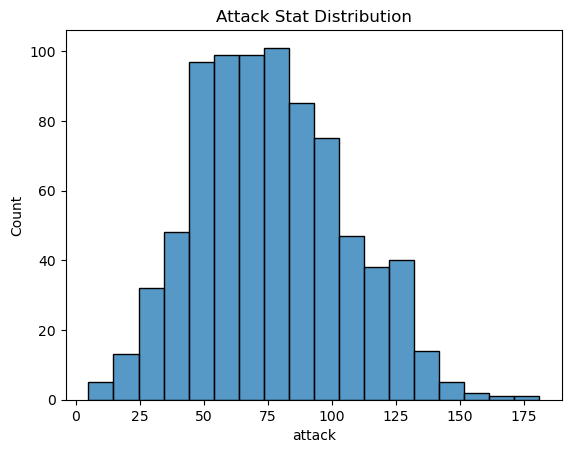

In [16]:
# Make a histogram for the attack stat
sns.histplot(data=pokemon_df['attack'], binwidth = 10)
plt.title('Attack Stat Distribution')
plt.show()

The attack stat seems fairly normal...maybe just a tad right-skewed. Let's take a look at its statistics.

In [17]:
# find summary statistics
pokemon_df['attack'].describe()

count    802.000000
mean      75.917706
std       29.490145
min        5.000000
25%       55.000000
50%       75.000000
75%       95.000000
max      181.000000
Name: attack, dtype: float64

As some other basic pointers: the mean is slightly less than the median (the 50th percentile), so again that means the data is likely a little bit right-skewed. Additionally, 3 standard deviations away from the mean (for normal distribution, 99.5% of the data) is roughly -14 and 166 (rounding the mean to 76 and the std to 30) -> both are to the left of the min (5) and max (181) respectively, another suggestion that the data is probably right-skewed.

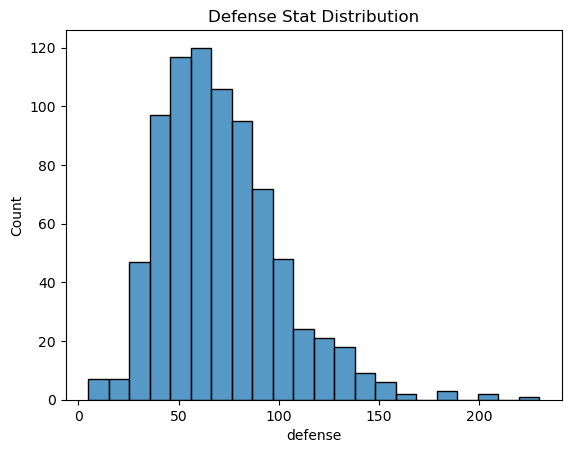

In [18]:
# Make a histogram for the defense stat
sns.histplot(data=pokemon_df['defense'], binwidth = 10)
plt.title('Defense Stat Distribution')
plt.show()

To me, this data is pretty clearly right skewed. However, I'm especially interested in the outliers above 200. Let's take a look with a box plot.

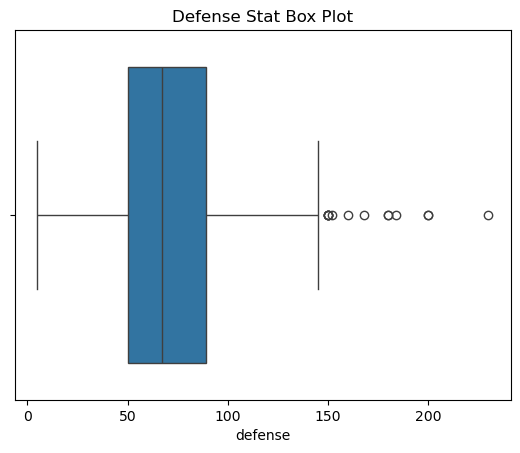

In [19]:
# Make a box plot for the defense stat
sns.boxplot(x=pokemon_df['defense'])
plt.title('Defense Stat Box Plot')
plt.show()

Wow, there's even more outliers than I estimated! Let's see exactly how many using IQR fences (the following code is pasted/edited from the Week_9_2 Jupyter Notebook).

In [20]:
# Compute Q1 and Q3 using numpy
Q1, Q3 = np.percentile(pokemon_df['defense'], [25,75])
IQR = iqr(pokemon_df['defense'])

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outlierdf = pokemon_df[(pokemon_df['defense'] < lower_bound) | (pokemon_df['defense'] > upper_bound)]

# print number of outliers (aka the number of rows in outlierdf)
print(f'Number of outliers for defense: {outlierdf.shape[0]}')

Number of outliers for defense: 14


Just out of curiosity, let's see what pokemon correspond to these outliers.

In [21]:
display(outlierdf)

,id,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
90,91,cloyster,91,1.5,132.5,184,water,ice,50,95,180,85,45,70,#6890F0,#98D8D8,#73A1EA,water3,NaN,//archives.bulbagarden.net/media/upload/8/84/091MS6.png,1.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/091.png
94,95,onix,95,8.8,210.0,77,rock,ground,35,45,160,30,45,70,#B8A038,#E0C068,#C1A743,mineral,NaN,//archives.bulbagarden.net/media/upload/3/38/095MS6.png,1.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/095.png
207,208,steelix,208,9.2,400.0,179,steel,ground,75,85,200,55,65,30,#B8B8D0,#E0C068,#C1B9B6,mineral,NaN,//archives.bulbagarden.net/media/upload/b/b5/208MS6.png,2.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/208.png
212,213,shuckle,213,0.6,20.5,177,bug,rock,20,10,230,10,230,5,#A8B820,#B8A038,#ABB225,bug,NaN,//archives.bulbagarden.net/media/upload/d/da/213MS6.png,2.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/213.png
305,306,aggron,306,2.1,360.0,239,steel,rock,70,110,180,60,60,50,#B8B8D0,#B8A038,#B8B2AB,monster,NaN,//archives.bulbagarden.net/media/upload/9/95/306MS6.png,3.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/306.png
376,377,regirock,377,1.7,230.0,261,rock,NaN,80,100,200,50,100,50,#B8A038,NaN,NaN,no-eggs,NaN,//archives.bulbagarden.net/media/upload/a/a7/377MS6.png,3.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/377.png
378,379,registeel,379,1.9,205.0,261,steel,NaN,80,75,150,75,150,50,#B8B8D0,NaN,NaN,no-eggs,NaN,//archives.bulbagarden.net/media/upload/c/c0/379MS6.png,3.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/379.png
410,411,bastiodon,411,1.3,149.5,173,rock,steel,60,52,168,47,138,30,#B8A038,#B8B8D0,#B8A55C,monster,NaN,//archives.bulbagarden.net/media/upload/d/d7/411MS6.png,4.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/411.png
679,680,doublade,680,0.8,4.5,157,steel,ghost,59,110,150,45,49,35,#B8B8D0,#705898,#A6A0C2,mineral,NaN,//archives.bulbagarden.net/media/upload/6/6d/680MS6.png,6.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/680.png
680,681,aegislash-shield,681,1.7,53.0,234,steel,ghost,60,50,150,50,150,60,#B8B8D0,#705898,#A6A0C2,mineral,NaN,//archives.bulbagarden.net/media/upload/2/25/681MS6.png,6.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/681.png


At least from my limited Pokemon knowledge, it checks out that some so-called 'tough' Pokémon like Onyx and Steelix (giant snakes made of rock and steel, respectively) correspond to such unusually high defense stats.

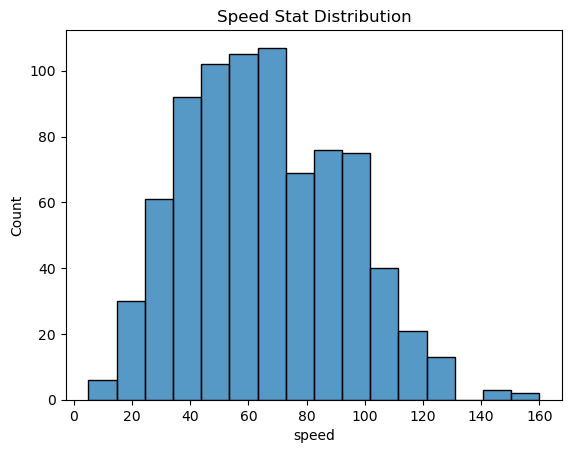

In [22]:
# Make a histogram for the speed stat
sns.histplot(data=pokemon_df['speed'], binwidth = 10)
plt.title('Speed Stat Distribution')
plt.show()

Yet again, we've got some pretty right-skewed looking data. Just for fun, I'd like to see what Pokémon(s) is/are the fastest.

In [23]:
# Find and print the fastest pokemon
fastest_pokemon = pokemon_df[pokemon_df['speed'] == pokemon_df['speed'].max()]
display(fastest_pokemon)

,id,pokemon,species_id,height,weight,base_experience,type_1,type_2,hp,attack,defense,special_attack,special_defense,speed,color_1,color_2,color_f,egg_group_1,egg_group_2,url_icon,generation_id,url_image
290,291,ninjask,291,0.8,12.0,160,bug,flying,61,90,45,50,50,160,#A8B820,#A890F0,#A8AE52,bug,NaN,//archives.bulbagarden.net/media/upload/9/9c/291MS6.png,3.0,https://raw.githubusercontent.com/HybridShivam/Pokemon/master/assets/images/291.png


And we have Ninjask! With a quick internet search (as I found here: https://pokemon.fandom.com/wiki/Ninjask), we see that lighting-fast speed is the characteristic trait of this Pokémon. Checks out!

### Section 2: Correlations & Group Comparisons

First off, let's look at the correlations between 'battle' stats (hp, attack, speed, defense, etc.)

In [24]:
# Make a new dataframe with only attack and defense
attack_defense = pokemon_df[['attack','defense','special_attack','special_defense', 'hp', 'speed', 'height', 'weight']].copy()
attack_defense.corr()

,attack,defense,special_attack,special_defense,hp,speed,height,weight
attack,1.000000,0.434038,0.324101,0.199429,0.436633,0.337937,0.409446,0.382348
defense,0.434038,1.000000,0.209323,0.509880,0.236128,-0.012408,0.349217,0.425444
special_attack,0.324101,0.209323,1.000000,0.484647,0.381264,0.433533,0.353267,0.230046
special_defense,0.199429,0.509880,0.484647,1.000000,0.368842,0.205873,0.307345,0.294890
hp,0.436633,0.236128,0.381264,0.368842,1.000000,0.168953,0.471145,0.424804
speed,0.337937,-0.012408,0.433533,0.205873,0.168953,1.000000,0.201214,0.043855
height,0.409446,0.349217,0.353267,0.307345,0.471145,0.201214,1.000000,0.627406
weight,0.382348,0.425444,0.230046,0.294890,0.424804,0.043855,0.627406,1.000000


Now we've got a lot of variables working here - it might be better if we used a heatmap.

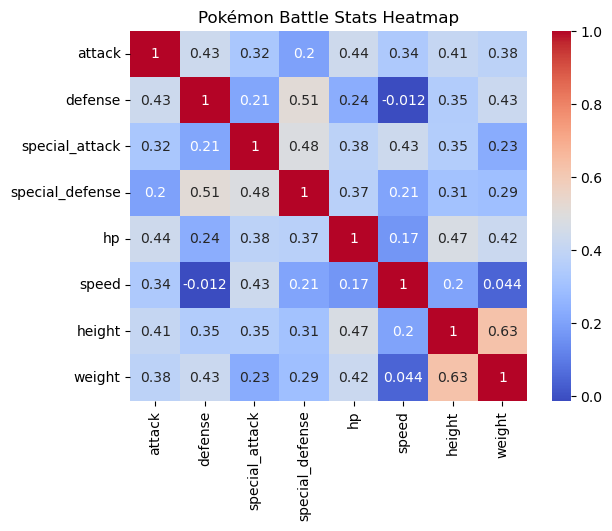

In [25]:
# Use a heatmap to visualize correlations
sns.heatmap(attack_defense.corr(), annot=True, cmap="coolwarm")
plt.title('Pokémon Battle Stats Heatmap')
plt.show()

Some highlights:

First off, we have one (small) negative correlation amongst these variables! As defense goes up, speed goes down. This makes intuitive sense since if you're more sturdy and tough, you will probably be slower. However, this looks suspicious as the correlation constant is very small. Similarly, a *very* tiny positive correlation exists between speed and weight, which means as a Pokémon gets heavier, don't count on it getting much faster.


Our highest correlation (besides between the same variable) is between height and weight - which makes sense, a taller Pokémon will probably be heavier as well. The next strongest correlations are between defense & special defense and special attack & special defense. This first one (defense & special defense) makes a good amount of sense because a 'tough' Pokémon is probably good at defending both physical and special attacks. The second one (special attack & special defense) also makes good sense because these correspond to 'special', kind of magic-like moves, so a Pokémon that prioritizes special moves likely gives and receives them well. 




Now let's take a look at some group comparisons. I'd like to compare across types, however there are a LOT of them, so lets limit the data to just the classic 3 starting types: water, grass, and fire.

In [26]:
# use a boolean mask to make a df of only the starting Pokemon types
starter_df = pokemon_df[(pokemon_df['type_1'] == 'water') | (pokemon_df['type_1'] == 'grass') | (pokemon_df['type_1'] == 'fire')]


Now lets see how a given stat (we'll go with speed) compares amongst these groups.

In [27]:
# use groupby() to see stats across different types
starter_df.groupby('type_1')['speed'].agg(['mean', 'min', 'max', 'std'])

,mean,min,max,std
type_1,,,,
fire,73.942308,20,126,24.043599
grass,58.871795,10,120,25.745689
water,63.745614,5,122,23.271317


On average it seems like fire is the fastest. Let's get a better look with a box plot.

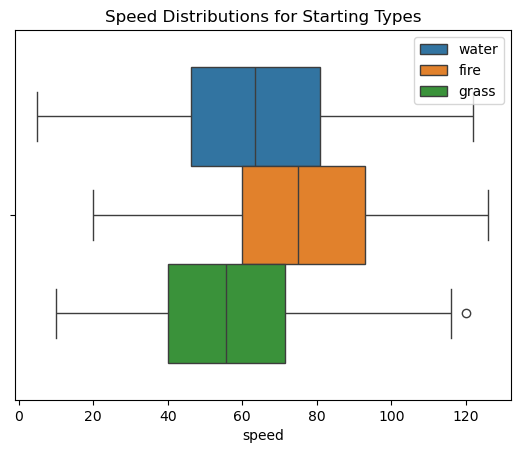

In [28]:
# Make a box plot for the speed of starter types
sns.boxplot(x=starter_df['speed'], hue = starter_df['type_1'],hue_order = ['water', 'fire', 'grass'])
plt.title('Speed Distributions for Starting Types')
plt.legend(loc='upper right')
plt.show()

Overall, the distributions are *pretty* similar, with fire being a little bit faster on average. I can see this making sense from a developer standpoint - these three types have a rock paper scissors kind of relationship (fire beats grass, grass beats water, water beats fire) - because of this existing, balanced relationship, it would make sense to keep speed roughly similar (maybe with a little push for fire types) to keep those scales balanced and not give one type a stark advantage over the other two.

Let's try to find a more apparent difference in distribution. I'd bet that bug type Pokémon tend to weigh much less than rock types. Let's give it a look.

In [29]:
# use a boolean mask to make a df of only bug and rock Pokemon types
bugrock_df = pokemon_df[(pokemon_df['type_1'] == 'bug') | (pokemon_df['type_1'] == 'rock')]

Let's see the stats!

In [30]:
# use groupby() to see stats across different types
bugrock_df.groupby('type_1')['weight'].agg(['mean', 'min', 'max', 'std'])

,mean,min,max,std
type_1,,,,
bug,33.083333,0.2,333.6,53.116974
rock,94.684444,5.7,340.0,93.287583


Looks like my suspicions were correct - a pile of rocks is probably going to weigh more than a bug. Let's confirm with a box plot.

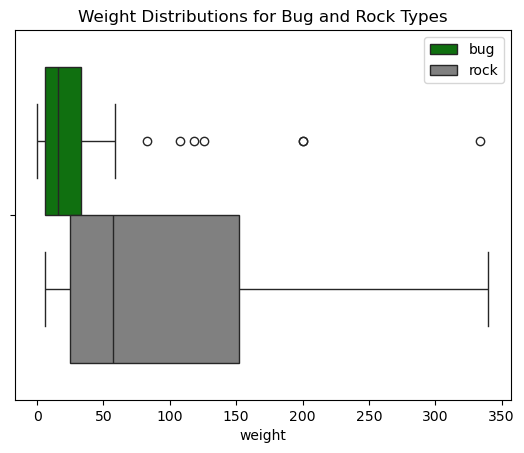

In [31]:
# Make a box plot for the speed of starter types
sns.boxplot(x=bugrock_df['weight'], hue = bugrock_df['type_1'], palette = ['green','grey'])
plt.title('Weight Distributions for Bug and Rock Types')
plt.legend(loc='upper right')
plt.show()

There we have it - with the exception of a few outliers (that's one heavy bug in there), rock types are both heavier on average and have more species in the heavier ranges (above 50 [whatever unit of weight this dataset uses - the website does not specify and different verisons of the game will use kgs or lbs]).

### Section 3: Advanced Visualizations

Back in Section 1, I talked about the interesting hierarchical nature of Pokémon with two types. Let's try and visualize that hierarchy.

In [32]:
# Use .groupby() and .size() to create a data frame of the counts of each double-type of Pokémon 
counts_df = pokemon_df.groupby(['type_1', 'type_2']).size().reset_index(name='count')
counts_df.head()

,type_1,type_2,count
0,bug,electric,4
1,bug,fairy,2
2,bug,fighting,3
3,bug,fire,2
4,bug,flying,13


Now that we have a dataframe of the counts of double types, we can plot these counts using a Plotly Sunburst chart.

In [33]:
import plotly.express as px

fig = px.sunburst(counts_df, 
                  path=['type_1','type_2'], 
                  values='count',
                  width = 1000,
                  height = 1000,
                  title="Sunburst: Amounts of Double-Typed Pokémon")

fig.show()

Here we can really easily see the design choices made when it comes to "typing" Pokémon. Just like how we saw in Section 1, flying is far more popular as a secondary type than a primary type. Since there's very few primary flying types (3 as we saw from Section 1), but there's 26 Normal-Flying types, that may suggest that for some reason, it's more balanced to give a basic flying Pokémon (like a generic bird) Normal-Flying rather than just Flying.

One thing to note is that this graph does NOT include single-typed Pokémon. However, this exclusion provides insights of its own. For example, from our initial value_counts in section 1, we see that there are 114 Pokémon with a primary type of water. However, as the sunburst chart shows, 53 of these are double-typed. So, about half of water types are single-typed and the other half are double typed. Still, water remains the most popular primary type, both in the total Pokemon dataset and the double-typed one.

One more interesting choice is with the ordering of double types. For example, there are 14 Grass-Poison and 0 Poison-Grass types, but there are 4 Water-Rock and 6 Rock-Water. I wonder if there's a difference in this ordering, i.e. if there are different advantages to being Water-Rock vs Rock-Water.

Going back to our correlations, I'd like to take a deeper dive into that one negative correlation we found between defense and speed. To get a potentially more informative result, let's make a regression plot.

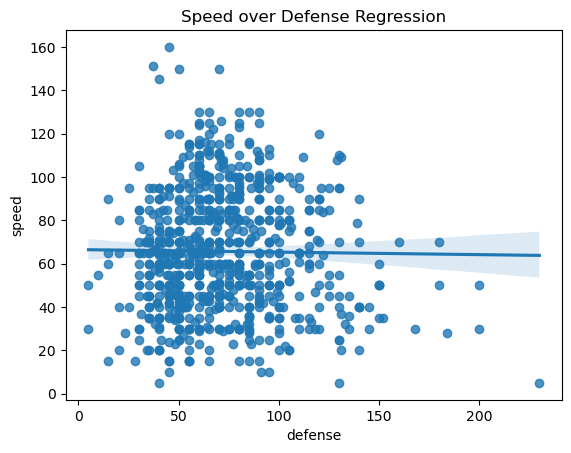

In [34]:
# Make a regression plot of defense and speed
reg = sns.regplot(data=pokemon_df,
            x='defense',
            y = 'speed')

# I had to do this different method for the title since plt.title() isn't working with the regression plot for some reason.
reg.set_title('Speed over Defense Regression')

plt.show()

Now before, with our correlation constants, we found this correlation to be a *very small* negative number, which already raised a red flag. We can see that tiny negative correlation in this regression plot which has a line with a ever so slight negative slope. However, now that we have the added context of both the confidence intervals and the scatter plot that corresponds to this relationship, we can pretty confidently say there's no correlation between these two variables. We will really set this in stone one more time with a hypothesis test in the next section.

Lastly, lets try to better visualize some of our distributions. We looked a good amount at attack and defense before, focusing on their individual distributions. What if we looked at them together? Let's visualize this using a kde plot (we'll use a contour plot as used in the Iris_Visualization notebook we followed in class).

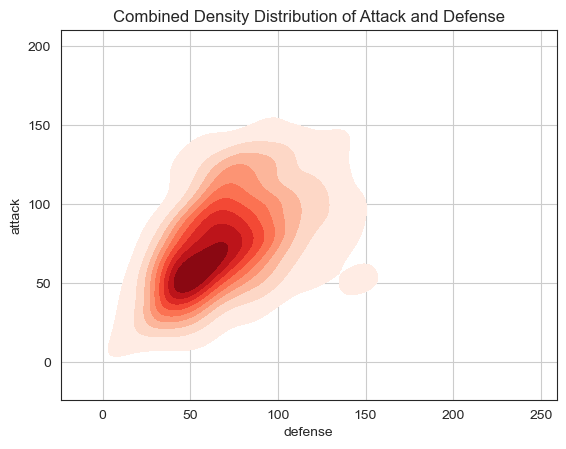

In [35]:
# Make a Contour Plot of Attack over Defense
sns.set_style("white")
kde = sns.kdeplot(x=pokemon_df.defense, y=pokemon_df.attack, cmap="Reds", fill=True)
plt.grid('on')

# Same error occured here, had to use set_title() method
kde.set_title('Combined Density Distribution of Attack and Defense')
plt.show()

Here we see that the most popular statline for attack and defense is right around 50-50. This sounds like a low number, but it may be explained by the games' evolution system. Some Pokémon can evolve into stronger species with higher stats like attack and defense, but there are also some that don't evolve. Because this leads to a larger amount of 'unevolved' than 'evolved' Pokémon, this may explain how lower attack and defense stats are more common.

Additionally, we can take a look at the darkest color along the line of a given amount of attack to see the most common corresponding defense stat and vice versa. For example, at 50 attack, ~50 defense is most likely. At 100 attack, ~75 defense is most likely, and at 100 defense, ~75 attack is most likely. This gives us the insight that once you get to higher attack levels, your defense stat will probably be lower than your attack stat, and the same goes for high-defense (likely lower attack).

### Section 4: Hypothesis Testing

Now let's run some formal tests to confirm some of the suspicions we've gathered from looking at parts of the data. 

A. Two-Sample Mean Test

In Section 2, we looked at boxplots to discover that the bug-type Pokémon are probably, on average, lower in weight than rock-types. Let's set up a test to confirm this.

Null Hypothesis (H0): There is no difference in the average weight of bug-type and rock_type Pokémon.

Alternate Hypothesis (Ha): Bug-types weigh less on average than rock-types.

Significance vartiable: 0.05

Let's run the test and compare the p-value to our significance variable.

In [36]:
# Run a two-sample mean test between the weights of bug and rock types
from scipy import stats

group_a = pokemon_df[pokemon_df["type_1"] == "bug"]["weight"]
group_b = pokemon_df[pokemon_df["type_1"] == "rock"]["weight"]

t_stat, p_value = stats.ttest_ind(group_a, group_b)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.8f}") # 8 decimal places used to view non-zero terms

t-statistic: -4.5519
p-value: 0.00001328


Here we can see that the p-value is EXTREMELY small (orders of magnitude less than 0.05). As a result, we can STRONGLY reject our null hypothesis. This means that there is most likely a significant difference in the average weight of bug and rock types. Pairing this up with our box plot from Section 2, we can confidently say that bug-types weigh less than rock-types on average.

B. Pearson Correlation Test

Now let's take one more look at our defense-speed correlation. In previous sections, we inferred that the negative correlation between the two stats is likely insignificant. Let's confirm with a test.

Null Hypothesis (H0): There is no significant correlation between defense and speed.

Alternate Hypothesis (Ha): Defense and speed stats have a significant negative correlation.

Significance vartiable: 0.05

Let's run the test!


In [37]:
# Run a pearson correlation test between defense and speed
r, p_value = stats.pearsonr(pokemon_df["defense"], pokemon_df["speed"])
print(f"Pearson r: {r:.4f}")
print(f"p-value: {p_value:.4f}")

Pearson r: -0.0124
p-value: 0.7257


Here, our p-value is MUCH higher than 0.05, so we cannot reject our null hypothesis. This means that this data is unable to prove that there is a significant correlation between defense and speed. It technically doesn't allow us to accept the null hypothesis, but it points us in the direction that the null hypothesis is likely the case.

For both of thesse tests, we have a very large sample size (802 rows of data) and therefore high statistical significance, so we can be pretty certain on the validity of the results of both tests.

### Section 5: Final EDA Summary

A. Summary of Major Findings

- The initial dataset had essential duplicates of the same Pokémon due to different "forms." Since these datapoints are uninteresting to us and would likely skew some statistics and distributions, we cleaned up the data by deleting the rows with these duplicates.
- Most Pokemon that are considered "flying" types have this as a secondary type
- The distributions of attack, defense, and speed are all likely right-skewed
- Of the major "battle" stats, height and weight are most strongly correlated
- Double-types of Pokemon can be ordered in different ways (ex: water-rock, rock-water)
- Bug types weigh less than rock types on average
- There is probably no significant correlation between defense and speed



B. Limitations and Caveats

- This dataset only goes up to Generation 7, and there are 9 generations of Pokémon now
- This dataset doesn't specify units for stats like height and weight
- There are missing values for the url_icon stat of Generation 7 Pokémon, so any application of icons would have to exempt Generation 7 using this dataset
- Potential sources of bias mostly stem from the visualizations used, such as the bin width of histograms

C. Next Steps
- To continue exploring, I'd look more into other variables I didn't get to as much here (like hp, special_attack and special_defense)
- If I could add more variables, it would maybe be ones that describe strength/weakness against other types (like how fire is strong against grass, weak against water), as I think a lot of interesting math can be done to, for example, find the type that is on average strongest against a given Pokémon.
- I think based on the explorations I did, one could make a predictive model that, for example, predicts the attack stat of a Pokémon given its defense stat. This may be useful in the creation of a new Pokémon that a developer would like to keep statistically balanced with the rest of the existing Pokémon in the games.